/root/miniconda3/envs/ML-TeIAS/lib/python3.7/site-packages/ipykernel_launcher.py:15: RuntimeWarning: divide by zero encountered in power
  from ipykernel import kernelapp as app


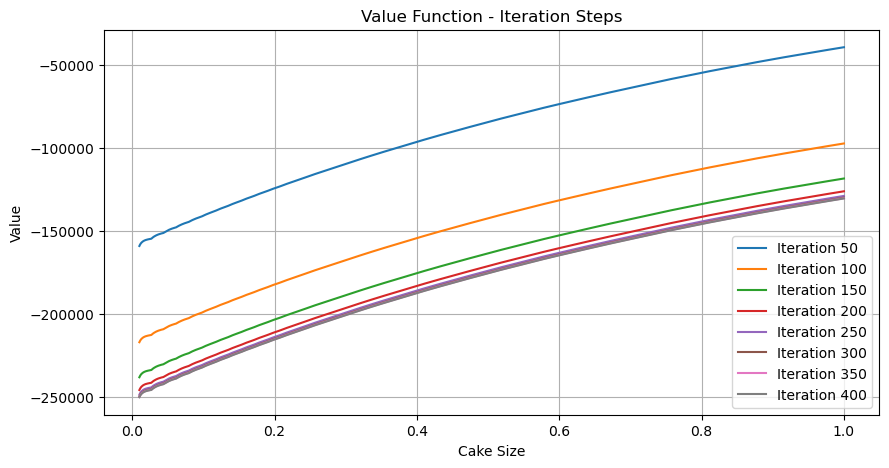

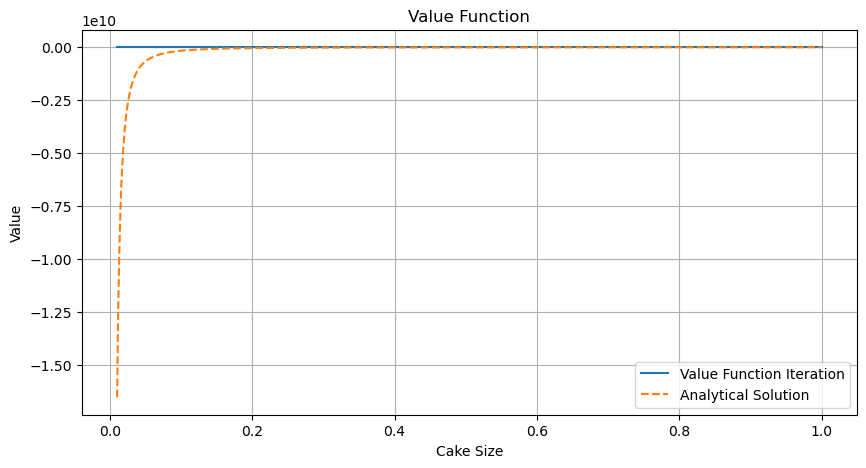

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters
sigma = 3  # Relative risk aversion coefficient
beta = 0.98  # Discount factor

# Maximum iterations and tolerance for convergence
max_iter = 10000
tol = 1e-6

# The utility function
def utility_function(c, sigma):
    # Calculate the utility based on consumption and risk aversion
    return np.where(c > 0, (c**(1-sigma)) / (1-sigma), -np.inf)

# Bellman equation right-hand side
def RHS(c, x, v, x_grid):
    # Interpolate the value function at x - c
    v_interp = np.interp(x - c, x_grid, v)
    # Calculate the right-hand side of the Bellman equation
    return utility_function(c, sigma) + beta * v_interp

# Update function for the value function
def T(v, x_grid):
    v_new = np.zeros(len(x_grid))
    for i in range(len(x_grid)):
        # Consumption range limited by the cake size
        consumption_range = np.linspace(0, x_grid[i], 100)
        # Find the maximum value and corresponding consumption using vectorized operations
        values = RHS(consumption_range, x_grid[i], v, x_grid)
        v_new[i] = np.max(values)
    return v_new

# Define the grid for cake size
x_grid = np.linspace(0.01, 1, 1000)

# Initialize value function
value_function = np.zeros(len(x_grid))

# Prepare the plot
plt.figure(figsize=(10, 5))

# Value function iteration
for iteration in range(max_iter):
    value_function_new = T(value_function, x_grid)
    # Plot the results at every 50th iteration
    if iteration % 50 == 49:
        plt.plot(x_grid, value_function_new, label=f'Iteration {iteration+1}')
    # Check for convergence using allclose
    if np.allclose(value_function, value_function_new, atol=tol):
        break
    value_function = value_function_new

# Finalize the plot
plt.title('Value Function - Iteration Steps')
plt.xlabel('Cake Size')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# The analytical solution for reference 
def analytical_value_function(x, sigma, beta):
    # Calculate the analytical solution based on the parameters
    return np.where(x > 0, (1 - beta**(1/sigma))**(-sigma) * utility_function(x, sigma), -np.inf)

# Plot the final value function
plt.figure(figsize=(10, 5))
plt.plot(x_grid, value_function, label='Value Function Iteration')
plt.plot(x_grid, analytical_value_function(x_grid, sigma, beta), label='Analytical Solution', linestyle='--')
plt.title('Value Function')
plt.xlabel('Cake Size')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()